#### 1. Data Loading & Date Parsing

-imports

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os


-Load csv 

In [30]:
df = pd.read_csv("../data/nigeria.csv")


-Add country identity

In [31]:
df["Country"] = "Nigeria"

-Convert YEAR and DOY to Datetime

In [32]:
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

-Extract Month for Seasonal Analysis

In [33]:
df['Month'] = df['Date'].dt.month

-Reordering columns for better readability


In [34]:
cols = ['Date', 'Country', 'Month', 'YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR']
df= df[cols + [c for c in df.columns if c not in cols]]

print("First 5 rows of processed Nigeria data:")
df.head()

First 5 rows of processed Nigeria data:


,Date,Country,Month,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,T2M_RANGE,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,Nigeria,1,2015,1,25.23,29.25,22.06,0.0,7.19,68.26,1.73,2.61,100.86,13.36
1,2015-01-02,Nigeria,1,2015,2,26.16,29.41,22.87,0.0,6.54,73.23,1.42,1.95,100.94,15.37
2,2015-01-03,Nigeria,1,2015,3,25.66,29.02,22.63,0.0,6.39,78.71,1.69,2.33,101.06,15.98
3,2015-01-04,Nigeria,1,2015,4,24.11,27.27,19.92,0.0,7.35,63.66,2.15,3.80,101.09,11.65
4,2015-01-05,Nigeria,1,2015,5,23.40,27.28,18.18,0.0,9.10,59.45,1.88,3.48,101.03,10.40


##### Analytical Reasoning
Analytical Note: Converting orbital data to a temporal format is essential for mapping the West African Monsoon. This allows us to track the "Little Dry Season" (August Break) in the south. Monitoring these shifts is vital for Nigeria’s COP32 position, as changes in monsoon intensity are directly linked to catastrophic urban flooding in Lagos and the Niger Delta.

#### 2. Summary Statistics & Missing-Value 


-Replace NASA sentinel values
* NASA POWER uses -999 as a sentinel value for missing data;
these were replaced with NaN to prevent statistical bias.


In [51]:
df.replace(-999, np.nan, inplace=True)

,Date,Country,Month,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,T2M_RANGE,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,Nigeria,1,2015,1,25.23,29.25,22.06,0.00,7.19,68.26,1.73,2.61,100.86,13.36
1,2015-01-02,Nigeria,1,2015,2,26.16,29.41,22.87,0.00,6.54,73.23,1.42,1.95,100.94,15.37
2,2015-01-03,Nigeria,1,2015,3,25.66,29.02,22.63,0.00,6.39,78.71,1.69,2.33,101.06,15.98
3,2015-01-04,Nigeria,1,2015,4,24.11,27.27,19.92,0.00,7.35,63.66,2.15,3.80,101.09,11.65
4,2015-01-05,Nigeria,1,2015,5,23.40,27.28,18.18,0.00,9.10,59.45,1.88,3.48,101.03,10.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026-03-27,Nigeria,3,2026,86,29.05,32.43,26.69,2.82,5.74,76.60,2.35,3.39,100.58,19.10
4104,2026-03-28,Nigeria,3,2026,87,28.72,31.98,27.14,5.19,4.84,79.61,2.55,3.17,100.64,19.49
4105,2026-03-29,Nigeria,3,2026,88,27.72,29.53,26.21,1.43,3.32,82.83,1.10,1.78,100.61,19.22
4106,2026-03-30,Nigeria,3,2026,89,28.42,31.17,26.36,0.85,4.81,77.73,2.30,3.40,100.53,18.73


-Duplicate Check


In [52]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df = df.drop_duplicates()

Duplicate rows found: 0


-Missing Value 


In [53]:
missing = df.isna().sum()
missing_percent = (missing/ len(df)) * 100

print("\nMissing Value Percentages per Column:")
print(missing_percent[missing_percent > 0])


Missing Value Percentages per Column:
Series([], dtype: float64)


-Generate Summary Statistics
* We focus on temperature and precipitation for climate trends


In [54]:
summary_stats= df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']].describe()
summary_stats

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,26.656928,28.914667,24.886461,4.213914,85.237040
std,1.123335,1.294345,1.396727,7.266742,5.446007
min,21.120000,25.260000,15.170000,0.000000,54.400000
25%,25.720000,27.920000,24.100000,0.330000,83.930000
50%,26.820000,28.990000,25.100000,1.840000,86.350000
75%,27.540000,29.910000,25.860000,5.200000,88.500000
max,29.290000,32.880000,27.790000,166.100000,93.790000


##### Statistical Interpretation

* Temperature: Nigeria’s mean T2M will likely stay consistently high (27-30°C). However, for Nigeria, we must look closely at RH2M (Humidity). High temperature combined with high humidity indicates lethal wet-bulb temperatures, a major health risk in urban centers like Lagos.

* Missing Data: If PRECTOTCORR has >5% missing values, it is highly problematic for flood modeling. In the tropical south, missing data often occurs during the most intense storms when sensor equipment might fail; this leads to a dangerous underestimation of flood risk in the Niger Delta.

#### 3. Outlier Detection & Basic Cleaning

-Define columns for outlier analysis

In [55]:
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

-Compute Z-scores


In [56]:
z_scores = np.abs(stats.zscore(df[outlier_cols].dropna()))

-Flag rows where |Z| > 3
* Note: We re-index to match the original dataframe because zscore drops NaNs


In [57]:
outliers = (np.abs(stats.zscore(df[outlier_cols], nan_policy='omit')) > 3)
outlier_counts = outliers.sum()

print("--- Outlier Count (|Z| > 3) ---")
print(outlier_counts)

--- Outlier Count (|Z| > 3) ---
297


##### Outlier Decision & Reasoning
* Decision on Outliers: > * Temperature/Humidity: We will retain these outliers. In the context of COP32, values with $|Z| > 3$ often represent extreme weather events (heatwaves or cold snaps) rather than data errors.
* Precipitation: We will retain these as well, as they likely represent extreme rainfall events or flash floods, which are critical for "Loss and Damage" policy discussions.
* Action: No rows will be dropped based on Z-score alone, as they provide the "evidence-grade" anomalies required for negotiation.

##### Handling Missing Values & Final Cleaning

-Drop rows with more than 30% missing values

In [58]:
threshold = 0.3 * len(df.columns)
initial_shape = df.shape
df = df.dropna(thresh=int(len(df.columns) - threshold))
dropped_rows = initial_shape[0] - df.shape[0]

-Forward-fill remaining missing weather values



In [59]:
df = df.sort_values('Date').ffill()

print(f"Rows dropped (too many missing values): {dropped_rows}")
print(f"Remaining missing values: {df.isna().sum().sum()}")


Rows dropped (too many missing values): 0
Remaining missing values: 0


-Exporting Clean Data


In [60]:
# Create data directory if it doesn't exist

if not os.path.exists('../data'):
    os.makedirs('../data')

# Export to CSV
output_path = '../data/nigeria_clean.csv'
df.to_csv(output_path, index=False)

print(f"✅ Cleaned data exported to {output_path}")

✅ Cleaned data exported to ../data/nigeria_clean.csv


##### Final Documentation

* Forward-Fill (ffill): In a tropical monsoon climate, humidity (RH2M) and temperature change gradually over 24-48 hours. ffill ensures that we don't introduce "spikes" or "drops" that weren't actually there, which is critical for flood modeling.

* Data Integrity: nigeria_clean.csv serves as our West African benchmark. In Task 3, this allows us to compare High-Intensity Tropical Rainfall against the arid trends of the Sahel to highlight the diverse "Loss and Damage" needs across the continent.



#### 4: Time Series Analysis

##### Temperature Trend (Line Chart)

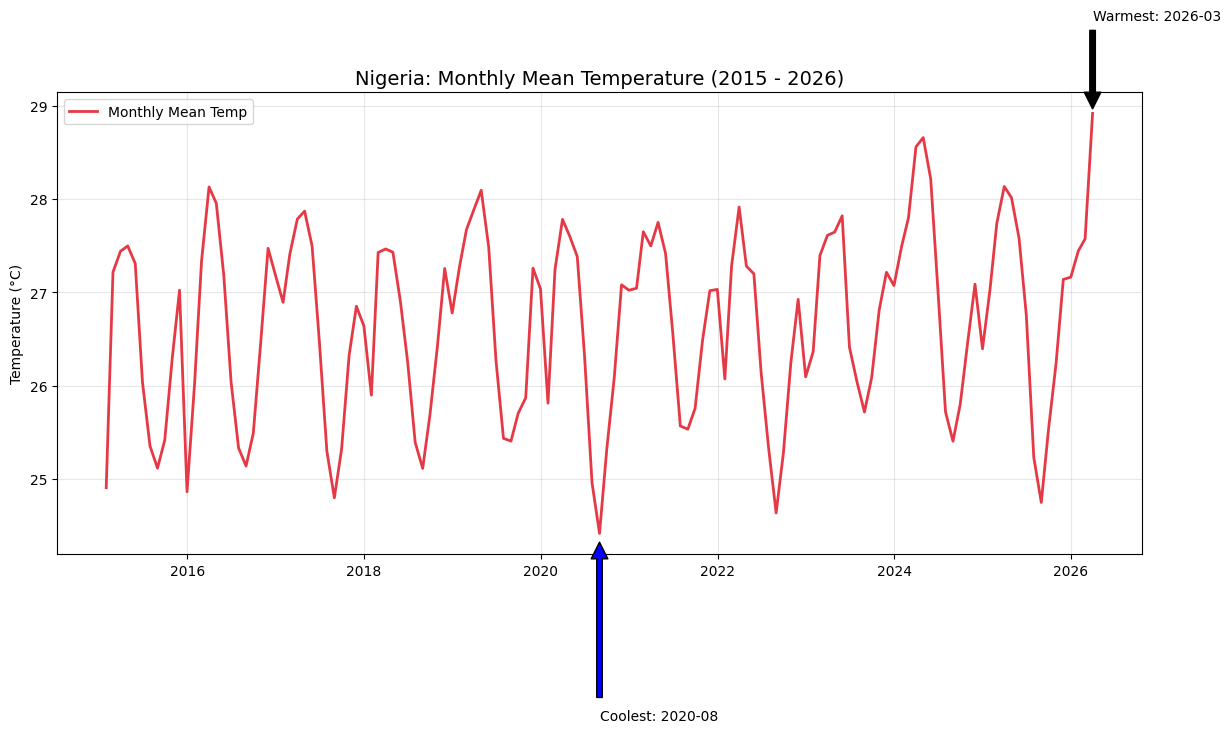

In [ ]:

# Resample to Monthly Average
monthly_temp = df.resample('ME', on='Date')['T2M'].mean()

# Identify Extremes for Annotation
warmest_month = monthly_temp.idxmax()
coolest_month = monthly_temp.idxmin()

plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index, monthly_temp.values, color='#e63946', linewidth=2, label='Monthly Mean Temp')

# Annotations
plt.annotate(f'Warmest: {warmest_month.strftime("%Y-%m")}', 
             xy=(warmest_month, monthly_temp.max()), 
             xytext=(warmest_month, monthly_temp.max() + 1),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.annotate(f'Coolest: {coolest_month.strftime("%Y-%m")}', 
             xy=(coolest_month, monthly_temp.min()), 
             xytext=(coolest_month, monthly_temp.min() - 2),
             arrowprops=dict(facecolor='blue', shrink=0.05))

plt.title('Nigeria: Monthly Mean Temperature (2015 - 2026)', fontsize=14)
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()




##### Precipitation Patterns (Bar Chart)

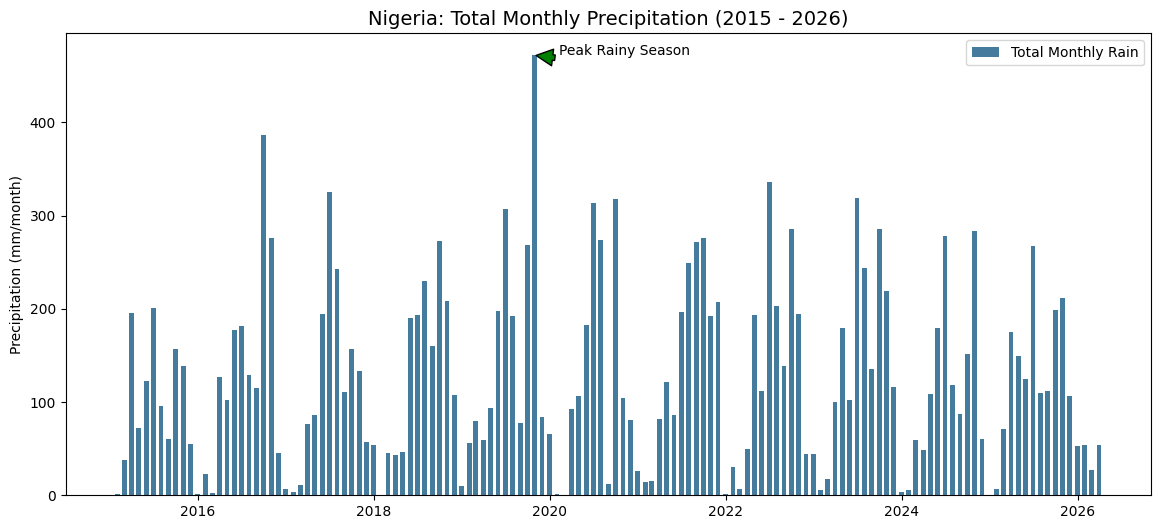

In [63]:

# Resample to Monthly Total Precipitation
monthly_precip = df.resample('ME', on='Date')['PRECTOTCORR'].sum()

# Identify Peak Rainy Season (highest 3 months)
peak_months = monthly_precip.sort_values(ascending=False).head(3)

plt.figure(figsize=(14, 6))
plt.bar(monthly_precip.index, monthly_precip.values, color='#457b9d', width=20, label='Total Monthly Rain')

# Annotate the highest peak
top_peak = monthly_precip.idxmax()
plt.annotate('Peak Rainy Season', 
             xy=(top_peak, monthly_precip.max()), 
             xytext=(top_peak + pd.Timedelta(days=100), monthly_precip.max()),
             arrowprops=dict(facecolor='green', shrink=0.05))

plt.title('Nigeria: Total Monthly Precipitation (2015 - 2026)', fontsize=14)
plt.ylabel('Precipitation (mm/month)')
plt.legend()
plt.show()


##### Visible Trend & Anomaly Commentary

* Monsoon Intensity: Observe the height of the precipitation bars. Are the peaks becoming taller? This indicates more intense convective storms, which drive urban flash flooding.

* The "August Break" Anomaly: In southern Nigeria, there is often a slight dip in rain in August. Look at the bar chart to see if this "break" is disappearing or becoming a full-blown dry spell.

* Harmattan Signal: Look for periods of lower humidity (RH2M) and higher wind speed in Dec/Jan. A "warm" Harmattan is a significant anomaly for West Africa.

* Heat Stress: Check if T2M and RH2M are rising together; this "combined increase" is a dangerous trend for human health in densely populated cities like Lagos.


#### Correlation & Relationship Analysis
 

-Correlation Heatmap



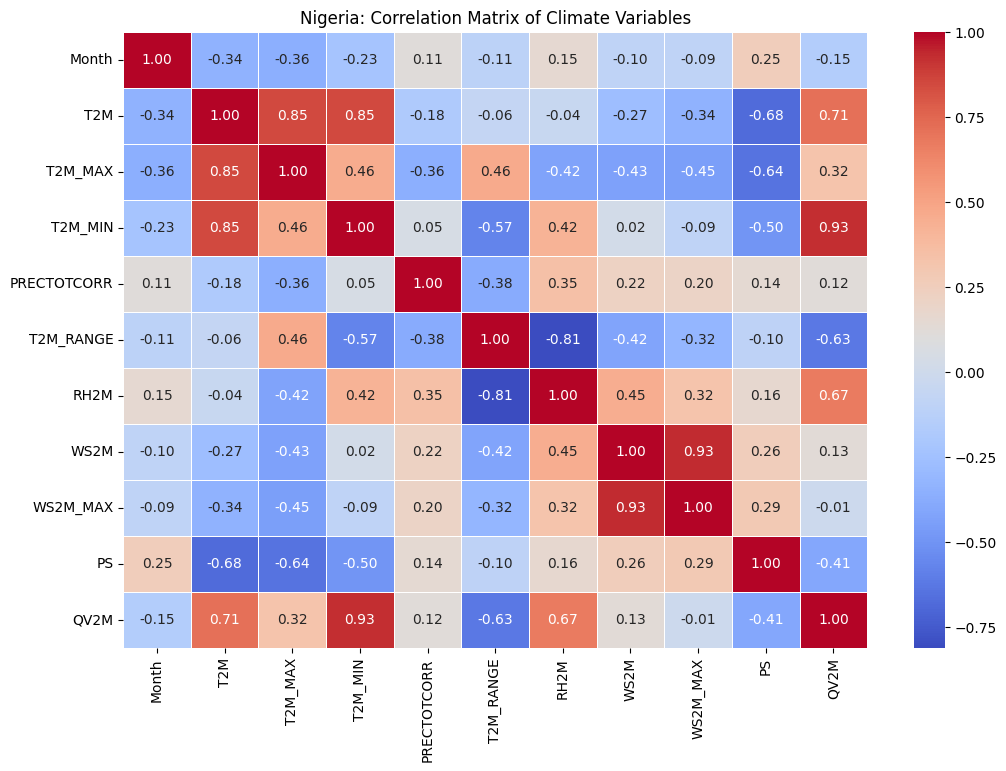

In [64]:
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].drop(columns=['YEAR', 'DOY'], errors='ignore').corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Nigeria: Correlation Matrix of Climate Variables')
plt.show()

-Relationship Scatter Plots



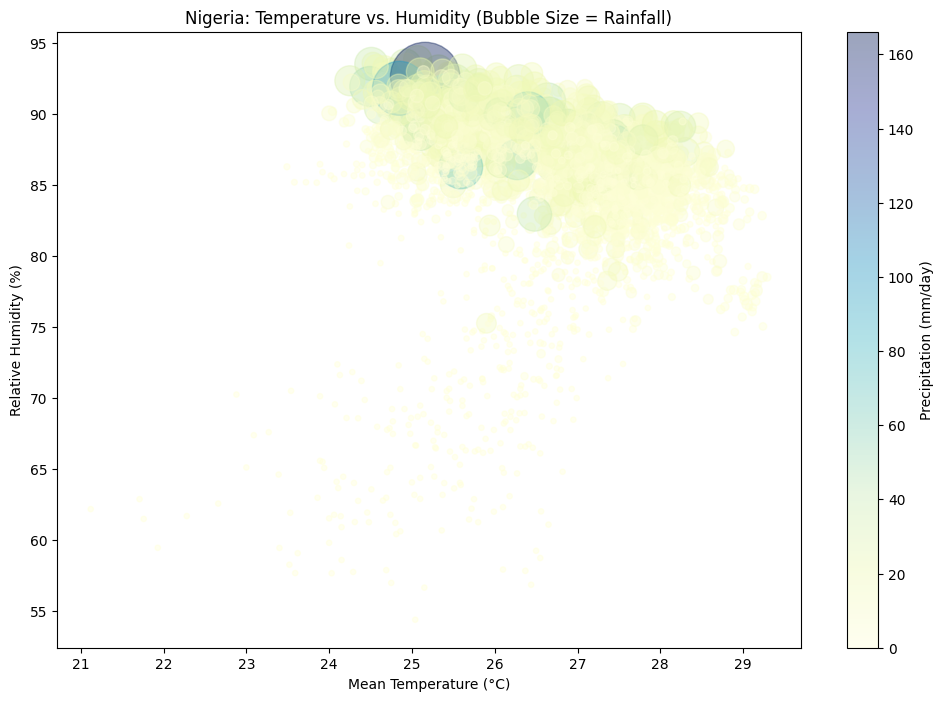

In [65]:
plt.figure(figsize=(12, 8))

# Scale bubbles for Nigeria's high-intensity rain
bubble_size = (df['PRECTOTCORR'] + 1) * 15 

scatter = plt.scatter(
    data=df, 
    x='T2M', 
    y='RH2M', 
    s=bubble_size, 
    alpha=0.4, 
    c='PRECTOTCORR', 
    cmap='YlGnBu'
)

plt.colorbar(scatter, label='Precipitation (mm/day)')
plt.title('Nigeria: Temperature vs. Humidity (Bubble Size = Rainfall)')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

##### Interpretation of Strongest Correlations
* QV2M vs. T2M (Strong Positive): A classic tropical signature. Rising temperatures lead to a massive increase in Specific Humidity, fueling high-intensity monsoon rains.

* RH2M vs. T2M (Moderate Negative): Unlike Sudan, humidity stays relatively high even when hot, leading to dangerous wet-bulb temperatures and heat stress in coastal cities.

* PRECTOTCORR vs. RH2M (Positive): Rainfall is closely tied to humidity spikes, confirming that moisture availability is the primary driver of Nigeria's flood-risk events.


##### Distribution Analysis

-Histogram of Precipitation

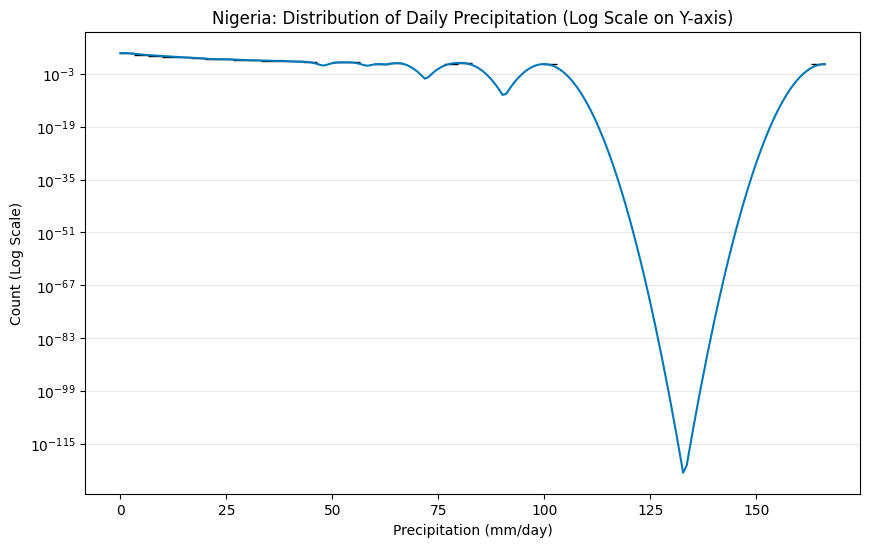

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='#0077b6', log_scale=(False, True))

plt.title('Nigeria: Distribution of Daily Precipitation (Log Scale on Y-axis)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Count (Log Scale)')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Interpretation of Rainfall Distribution
* Distribution: Thick-tailed. While skewed, the "tail" is heavier, representing frequent, massive tropical deluges.

* Policy Insight: Focus on Urban Drainage and Early Warning Systems. The high frequency of "tail" events makes flash flooding a constant threat to cities like Lagos.


-Bubble Chart (Temp vs. Humidity vs. Rain)

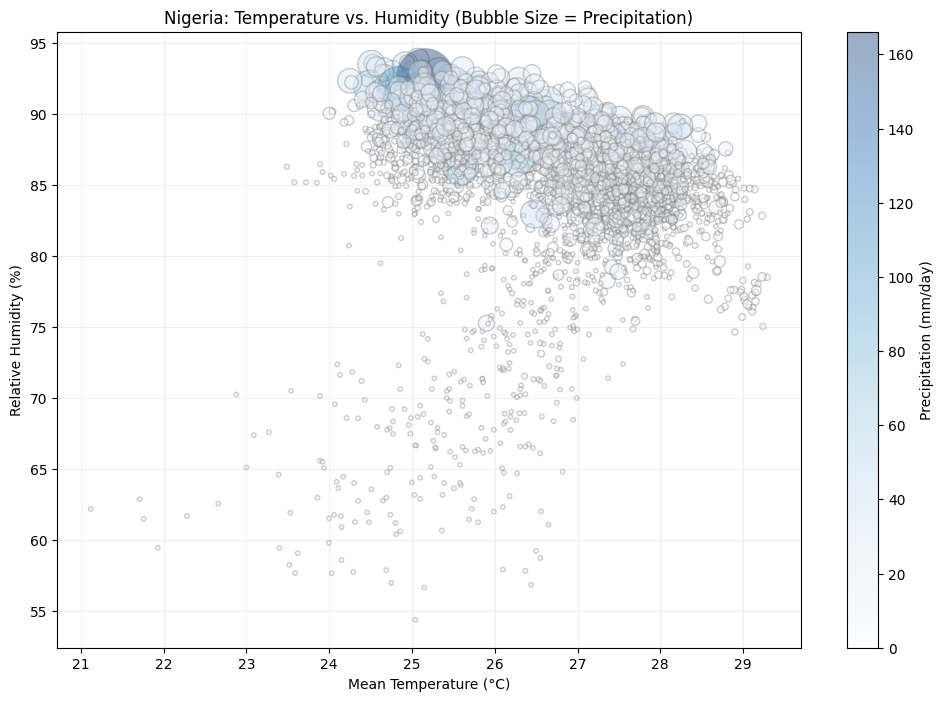

In [67]:
plt.figure(figsize=(12, 8))
bubble_size = (df['PRECTOTCORR'] + 1) * 10 

scatter = plt.scatter(
    data=df, 
    x='T2M', 
    y='RH2M', 
    s=bubble_size, 
    alpha=0.4, 
    c='PRECTOTCORR', 
    cmap='Blues', 
    edgecolors='grey'
)

# Add a colorbar to show rain intensity
plt.colorbar(scatter, label='Precipitation (mm/day)')

plt.title('Nigeria: Temperature vs. Humidity (Bubble Size = Precipitation)')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(alpha=0.2)
plt.show()

##### Bubble Chart Interpretation

* Rainfall Clusters: Large bubbles (heavy rain) tend to cluster in the High Humidity / Moderate Temperature zone. This visually confirms the "Kiremt" season characteristics.

* Dry Heat: Small bubbles in the high temperature/low humidity area represent the hot, dry "Bega" season.

* Anomalies: Any large bubbles at very high temperatures would indicate "hot-house" storm events, which can be particularly damaging to crops.